In [9]:
import numpy as np
import xarray as xr
from pathlib import Path
import awkward as ak
from typing import Tuple, List

import matplotlib.pyplot as plt
from sdm_eurec4a.visulization import set_custom_rcParams, plot_one_one, label_from_attrs, save_figure, ncols_nrows_from_N, _dark_colors
from sdm_eurec4a.reductions import mean_and_stderror_of_mean
from sdm_eurec4a.constants import TimeSlices
from cycler import cycler


from pySD.sdmout_src import supersdata
from pySD.sdmout_src import pygbxsdat, pysetuptxt, supersdata

plt.style.use("petroff10")

from sdm_eurec4a import RepositoryPath  #

RP = RepositoryPath("levante_m300950")


In [10]:

microphysics = [
    "coalbure_condensation_large",
    "coalbure_condensation_small",
    "collision_condensation",
    "condensation",
    "null_microphysics"
]

file_paths = [RP.CLEO_data_dir / "output_v4.2" / mp / "combined" / "conservation_dataset_combined.nc" for mp in microphysics]
datasets = [xr.open_dataset(fp) for fp in file_paths]

# use name of microphysics as coordinate
ds = xr.concat(datasets, dim=xr.DataArray(microphysics, dims="microphysics"), coords="all", join="outer")
# ds = ds.sel(time=TimeSlices.quasi_stationary_state)
ds = ds.isel(time=slice(0, -2))

ds["source"].attrs.update(long_name="Evaporation")

invalid_conservation_clouds = list({391, 393, 542, 164, 165, 166, 549, 569, 81, 83, 86, 88, 89, 92, 95, 486, 492, 239, 371, 250, 381, 127})
valid_clouds = list(set(ds["cloud_id"].values) - set(invalid_conservation_clouds))

In [11]:
# Create the mass conservations for all
total_data = ds["inflow"] + ds["outflow"] + ds["source"] - ds["reservoir_change"]

total_data.attrs.update(
    long_name=r"Sum of all terms $\left(I+O+S - \frac{dR}{dt}\right)$",
    units=ds["inflow"].attrs["units"],
)
ds["total"] = total_data


In [12]:
rolling_time_window = 20
variables_to_plot = ["inflow", "reservoir_change", "outflow", "source", "total"]
np.random.seed(42)
number_clouds = 4
random_cloud_ids = np.random.choice(valid_clouds, size=number_clouds, replace=False)
invalid_cloud_ids = np.random.choice(invalid_conservation_clouds, size=number_clouds, replace=False)

In [13]:

def plot_conservation_terms(ds, cloud_ids : List[int], plot_microphysics : str, variables_to_plot: List[str], rolling_time_window: int = 2):
    """
    This function plots the conservation terms for the given cloud_ids and microphysics scheme. It creates a figure with subplots for each cloud_id, where each subplot shows the rolling mean of the conservation terms over time.

    Parameters:
    ds (xarray.Dataset): The dataset containing the conservation terms.
    cloud_ids (List[int]): A list of cloud IDs to plot.
    plot_microphysics (str): The microphysics scheme to select from the dataset.
    variables_to_plot (List[str]): A list of variable names to plot. These should correspond to the conservation terms in the dataset.
    rolling_time_window (int): The size of the rolling window for calculating the mean. Default
    is 2.

    Returns:
    fig (matplotlib.figure.Figure): The figure object containing the subplots.
    axs (numpy.ndarray): An array of axes objects corresponding to the subplots.
    """


    ds_plot = ds.sel(microphysics=plot_microphysics)
    # create a figure with subplots for each cloud_id in invalid_conservation_clouds
    fig, axs = plt.subplots(figsize=(12, 6), sharex=True, **ncols_nrows_from_N(len(cloud_ids)))

    # for each cloud_id, plot the conservation terms
    for ax, cloud_id in zip(axs.flatten(), cloud_ids):
        for variable in variables_to_plot:
            x = ds_plot["time"]
            y = ds_plot[variable].sel(cloud_id=cloud_id).rolling(time=rolling_time_window).mean(keep_attrs=True)
            lines = ax.plot(x, y, label=label_from_attrs(y, return_units=False))
            ax.set_title(f"Cloud ID: {cloud_id}", fontsize=7)
            ax.axhline(0, color = "g", linestyle = "-", linewidth = 0.5, alpha = 0.5, zorder = 0)
            
    # create legend in last axes with the lines from the last cloud_id
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), prop={'size': 10, 'weight': 'bold'}, frameon=False)
    fig.supylabel(f"Mass change terms {label_from_attrs(y, return_name = False)}\nRolling window of {rolling_time_window:.0f} time steps applied", fontsize=12, weight='bold')
    fig.supxlabel(label_from_attrs(x) + f"\nMicrophysics: {plot_microphysics}", fontsize=12, weight='bold')
    fig.suptitle(f"", fontsize=12, weight='bold')        
    fig.tight_layout()

    return fig, axs

## Plot the mass conservation for random clouds

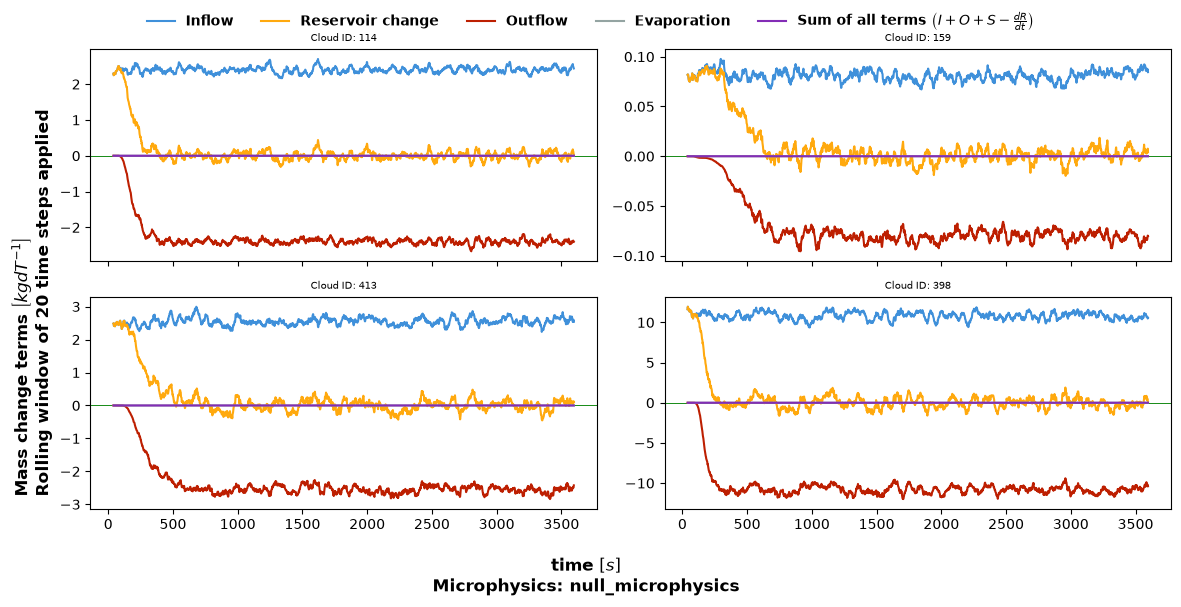

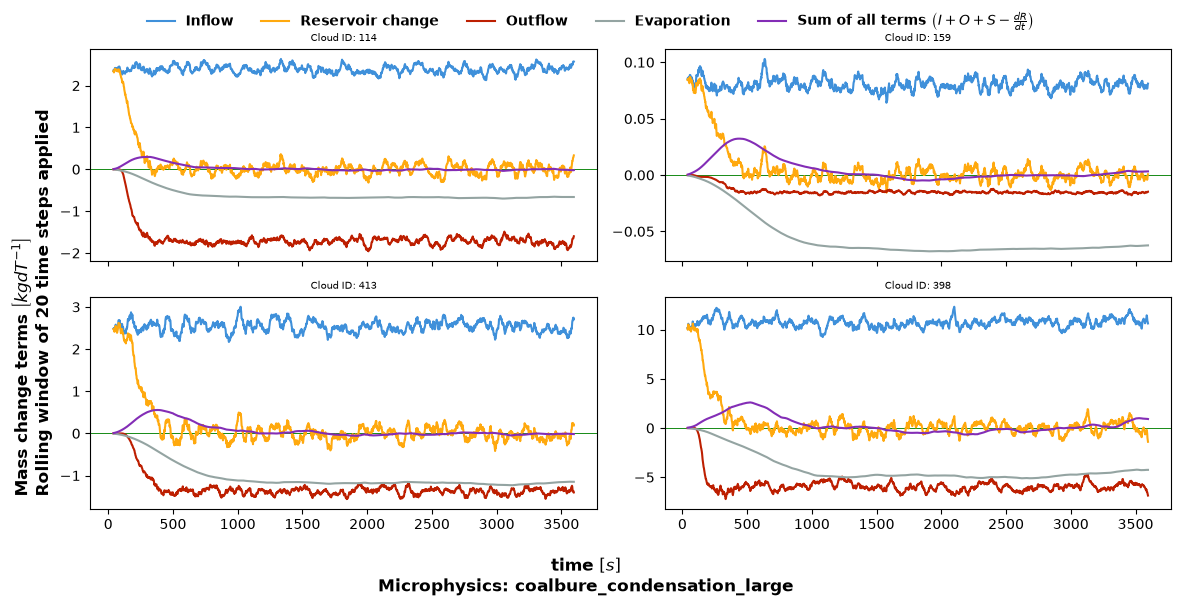

In [14]:
plot_conservation_terms(ds, random_cloud_ids, "null_microphysics", variables_to_plot, rolling_time_window);
plot_conservation_terms(ds, random_cloud_ids, "coalbure_condensation_large", variables_to_plot, rolling_time_window);

## Invalid clouds

It is visible below, that the outflow is 0 for all the clouds.

In the paper notebook, we compare the sum of all terms to inflow, outflow and source.

We call all clouds invalid, for which the sum of all terms is at least 1/10th compared to any of the inflow, outflow and source.
Therefore, if outflow is 0, the fraction explodes. 
For these Virga clouds (complete evaporation), the outlier check is thus not valid. 

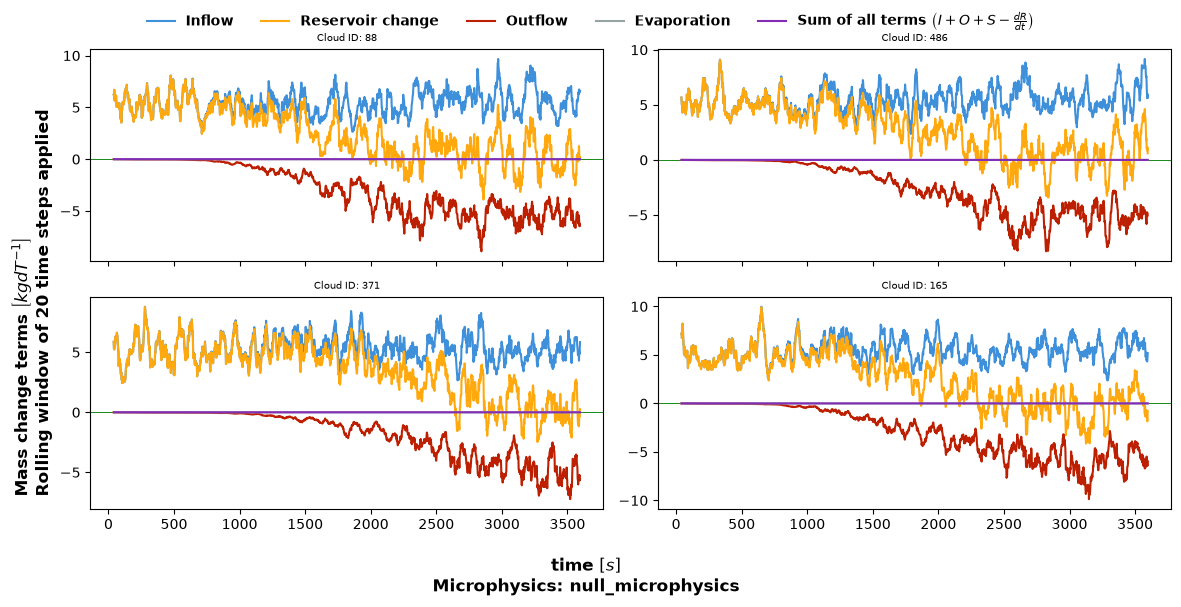

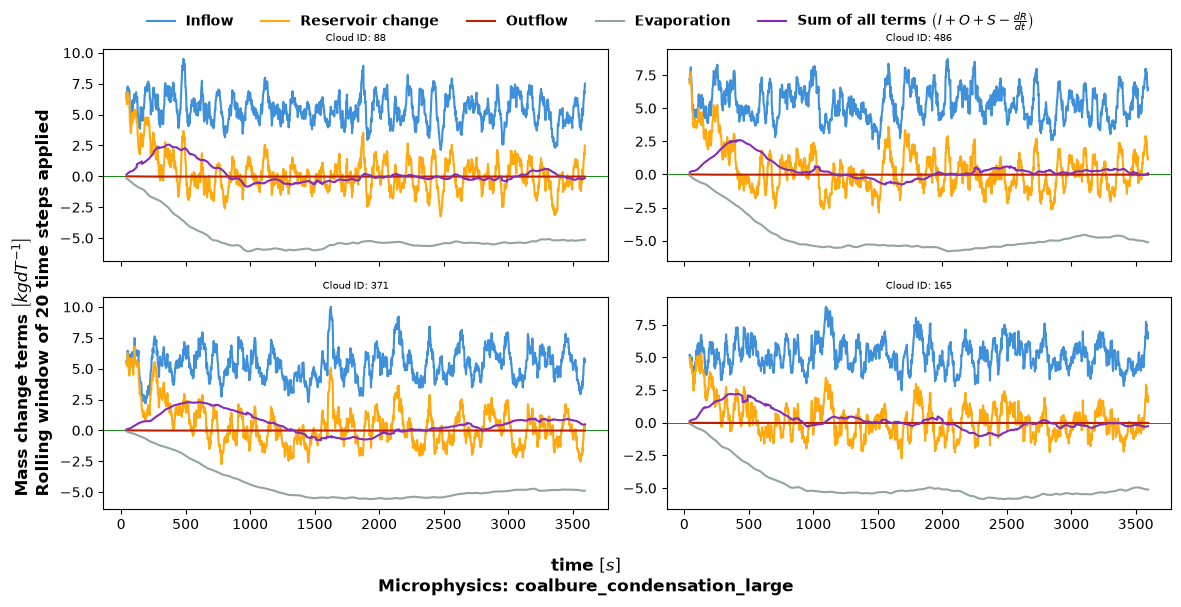

In [15]:
plot_conservation_terms(ds, invalid_cloud_ids, "null_microphysics", variables_to_plot, rolling_time_window);
plot_conservation_terms(ds, invalid_cloud_ids, "coalbure_condensation_large", variables_to_plot, rolling_time_window);

In [16]:
from sdm_eurec4a import data_loading


cleo_dataset = data_loading.CleoDataset(
    data_dir=RP.CLEO_data_dir /"output_v4.2",
    microphysics=tuple(microphysics),
)

coalbure_condensation_large


/home/m/m301096/repositories/yoctoyotta1024-sdm-eurec4a/src/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])


coalbure_condensation_small


/home/m/m301096/repositories/yoctoyotta1024-sdm-eurec4a/src/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])


collision_condensation


/home/m/m301096/repositories/yoctoyotta1024-sdm-eurec4a/src/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])


condensation


/home/m/m301096/repositories/yoctoyotta1024-sdm-eurec4a/src/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])


null_microphysics


/home/m/m301096/repositories/yoctoyotta1024-sdm-eurec4a/src/sdm_eurec4a/data_loading.py:413: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_single_sem = xr.merge([ds_conser_sem, ds_euler_sem])
/home/m/m301096/repositories/yoctoyotta1024-sdm-eurec4a/src/sdm_eurec4a/data_loading.py:423: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'cloud_id' ('cloud_id',) The recommendation is to set join explicitly for this case.
  ds = x